In [1]:
%config InlineBackend.figure_formats = ['svg']
import numpy as np  # noqa
import matplotlib as mpl  # noqa
import matplotlib.pyplot as plt  # noqa
import quimb as qu  # noqa
import xyzpy as xyz  # noqa
import autoray as ar  # noqa
import cotengra as ctg  # noqa
import quimb.tensor as qtn  # noqa

mpl.style.use(xyz.get_neutral_style(draw_color="black"))
import sys
import matplotlib as mpl
from matplotlib.ticker import MaxNLocator

sys.path.append("..")
import simpclustlib

mpl.rcParams["font.family"] = "Inter"

/media/johnnie/Storage2TB/Sync/work/simpclust/tn-loop-cluster-expansions/figs/../simpclustlib.py:19: FutureWarning: The module 'quimb.tensor.tensor_arbgeom' is deprecated and will be removed in a future release. Most functionality can be still be accessed directly from 'quimb.tensor' instead. The actual implementations have moved to `quimb.tensor.tnag.core`.
  from quimb.tensor.tensor_arbgeom import TensorNetworkGenVector


In [2]:
color_ref = (0.5, 0.8, 0.2)
color_sc = (0.1, 0.4, 0.7)
# color_sc = (1.0, 0.6, 0.2)
color_gl = (0.8, 0.2, 0.8)
color_gl_dark = (0.4, 0.1, 0.4)

yvar = "energy_gloop_expand"
yvar_alt = "energy_gloop_expand_norm_sum"

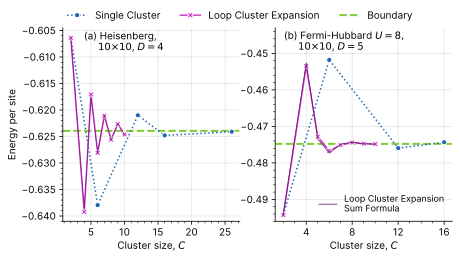

In [3]:
fig, axs = plt.subplots(figsize=(7, 3.5), ncols=2)

model = "heis"
geom = "square_obc"
L = 10
D = 4
ax = axs[0]


ds_sc = (
    xyz.load_ds(f"../data/energy_cluster_{model}_{geom}.h5")
    .squeeze()
    .sel(L=L, D=D)
)
x = ds_sc["max_size"].values
x = [2, 6, 12, 16, 26]
y = ds_sc["energy_cluster"].values
ax.plot(
    x,
    y,
    label="Single Cluster",
    linestyle=":",
    color=color_sc,
    marker="p",
    markeredgecolor="white",
)

ds_gl = (
    xyz.load_ds(f"../data/energy_gloop_expand_{model}_{geom}.h5")
    .squeeze()
    .sel(L=L, D=D)
)
ds_gl["max_size"] = ds_gl["max_size"].clip(2, None)
x = ds_gl["max_size"].values
y = ds_gl[yvar].values
y_alt = ds_gl[yvar_alt].values
ax.plot(
    x,
    y,
    label="Loop Cluster Expansion",
    color=color_gl,
    marker="X",
    markeredgecolor="white",
)
ax.plot(
    x,
    y_alt,
    color=color_gl_dark,
    marker="",
    markeredgecolor="white",
    linewidth=0.5,
)

ds_ref = (
    xyz.load_ds(f"../data/energy_full_{model}_{geom}.h5")
    .squeeze()
    .sel(
        symm="U1",
        L=L,
        D=D,
        chi=128,
    )
)
ax.axhline(
    ds_ref["energy"].item(),
    linestyle="--",
    color=color_ref,
    label="Boundary",
    zorder=-10,
    linewidth=2,
)

ax.set_ylabel("Energy per site")
ax.set_ylim(-0.641, -0.6045)
ax.set_xlabel("Cluster size, $C$")
ax.set_xscale("linear")
ax.text(
    0.12,
    0.98,
    f"(a) Heisenberg,\n     ${L}{{\\times}}{L}$, $D{{=}}{D}$",
    ha="left",
    va="top",
    transform=ax.transAxes,
)
ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=6))

ax.legend(bbox_to_anchor=(1.0, 0.99), ncol=3, loc="lower center")


model = "fermi_hubbard_U8"
geom = "square_obc"
L = 10
D = 5
ax = axs[1]

ds_sc = (
    xyz.load_ds(f"../data/energy_cluster_{model}_{geom}.h5")
    .squeeze()
    .sel(L=L, D=D)
)
x = ds_sc["max_size"].values
x = [2, 6, 12, 16]
y = ds_sc["energy_cluster"].values
ax.plot(
    x,
    y,
    # label="Single Cluster",
    linestyle=":",
    color=color_sc,
    marker="p",
    markeredgecolor="white",
)
ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=4))

ds_gl = (
    xyz.load_ds(f"../data/energy_gloop_expand_{model}_{geom}.h5")
    .squeeze()
    .sel(L=L, D=D)
)
ds_gl["max_size"] = ds_gl["max_size"].clip(2, None)
x = ds_gl["max_size"].values
y = ds_gl[yvar].values
y_alt = ds_gl[yvar_alt].values
ax.plot(x, y, color=color_gl, marker="X", markeredgecolor="white")
ax.plot(
    x,
    y_alt,
    color=color_gl_dark,
    marker="",
    markeredgecolor="white",
    linewidth=0.75,
    label="Loop Cluster Expansion\nSum Formula",
)


ds_ref = (
    xyz.load_ds(f"../data/energy_full_{model}_{geom}.h5")
    .squeeze()
    .sel(
        symm="U1",
        L=L,
        D=D,
        chi=128,
        site_charge="uniform-1",
    )
)
ax.axhline(
    ds_ref["energy"].item(),
    linestyle="--",
    color=color_ref,
    zorder=-10,
    linewidth=2,
)
ax.set_ylim(-0.496, -0.443)

ax.legend(fontsize=9)
ax.set_xlabel("Cluster size, $C$")
ax.text(
    0.05,
    0.98,
    f"(b) Fermi-Hubbard $U{{=}}8,$\n     ${L}{{\\times}}{L}$, $D{{=}}{D}$",
    ha="left",
    va="top",
    transform=ax.transAxes,
)

plt.show()
plt.close()

In [4]:
fig.savefig(
    "fig-energy-cluster-vs-expansion.png", dpi=300, bbox_inches="tight"
)